## Signals

Signals are representations of physical processes captured by sensors. For instance, this figure shows the average knee angle during the gait cycle, captured by sensors attached to the leg during multiple steps.


<div style="text-align: center;">
<img src='images/knee_angle.png', width=600, height=350>
</div>

When measuring a biological system, these signals (biosignals) measure the different processes that occur during the function (normal or abnormal) of the organism. These signals act as indicators of physiological states and bodily functions. Here is the same knee angle measure, but estimated for young and old individuals; notice the reduction in range of motion for older adults.

<div style="text-align: center;">
<img src='images/knee_angle_youngvsold.png', width=600, height=350>
</div>

It is important to understand that biosignals are a representation of the biological process that is being measured; they do not fully represent or characterize the functioning of the biological system being measured. For instance, 

- The above signals represent only the flexion-extension of the knee in the sagittal plane, but the knee also moves in other planes during gait (abduction/adduction, and internal/external rotation), which are not captured by this measure. 

- Muscle contraction is a complex process that involves electrochemical interactions that are affected by the muscle fibers state, length, and contraction speed. Muscle contraction is typically measured using electromyography (EMG), which quantifies the change in voltage (electrical component) across the muscle surface. Thus, the biosignal commonly used to quantify muscle contraction, the EMG signal, only measures one aspect of this biological process. 


### Common biosignals
- Electromyography (EMG): Measurement of electrical activity during muscle contraction.
- Photoplethysmography (PPG): Measurement of blood volume changes in the microvascular tissue, commonly used to monitor heart rate and oxygen saturation.
- Electroencephalogram (EEG): Measurement of the brain's spontaneous electrical activity, measured using electrodes placed on the scalp. These signals represent post-synaptic potentials of neurons.
- Electrocardiogram (ECG): Measurement of the heart's electrical activity over time.
- Electrodermal Activity (EDA): Measurement of sweat gland activity—controlled by the sympathetic nervous system—to indicate physiological arousal, stress, or emotional intensity
- Inertial Measurement Units (IMUs): Measurement of 3D acceleration and angular velocity, which are used to track human movement


### Noise

Biosignals typically emerge from sources deep inside the human body. Thus, these signals are small and are captured with sensitive sensors that must amplify the signal so that it can be interpreted. During the measurement process, it is (VERY) common to capture exogenous signals not related to the biological process. These signals are called noise, and they are combined with the biosignal at the origin, so it is difficult to separate/distinguish between the desired signal and the noise. 

Common sources of noise include:

- *Power line*: Electronic measurement systems capture a signal that originates from the power line. The signal is a sinusoidal with a 50 Hz or 60 Hz frequency (60Hz in America, 50Hz in most other countries). This figure shows an example of an EMG signal with power line interference.
<div style="text-align: center;">
<img src='images/EMG_noise_powerline.png' alt='EMG noise power line',width=800, height=600 >
</div>

Most modern measurement systems can mitigate power line interferences and minimize their effect on the measured biosignal. 

- *Movement artifacts*: Movement can interfere with the sensors capturing the biosignal and render the signal unusable. This figure shows an example of a PPG signal with motion artifacts.
<div style="text-align: center;">
<img src='images/EMG_noise_movement.png' alt='EMG noise movement',width=600, height=400>
</div>

Modern biosensing systems typically include movement sensors to mitigate the effect of motion (or at least indicate the presence of these artifacts in the signal).

- *Other physiological sources*: Most sources of biosignals are deep within the body, making it difficult to separate the signals provided by different sources. This figure shows an example of an EMG signal captured from the chest muscles that includes undesired measurements of heart activity.
<div style="text-align: center;">
<img src='images/EMG_and_EKG.png' alt='EMG and EKG noise',width=600, height=400>
</div> 

- *Random noise*: The electronic equipment used in the sensors induces different sources of electronic random noise, including thermal noise, shot noise, or 1/f noise, that corrupt, mask, or distort the weak biological signals. This noise is observed as random oscillations in the signal. This figure shows an example of an ECG signal with random noise.
<div style="text-align: center;">
<img src='images/ECG_multinoise.png' alt='ECG with multi noise',width=700, height=500>
</div> 



### Filtering

Filtering refers to removing some unwanted components of your signal. By filtering your signal, you can enhance the important component while minimizing the *noise*.

There are many techniques for signal filtering, and new filter designs can be developed for specific needs. 

_Note_: Filters can be used to separate different components of a signal; these components are not necessarily noise, it depends on the application. 

- *Median Filter*: A median filter replaces every value in a signal with the median value of a small window around the value.

<div style="text-align: center;">
<img src='images/med_filter_1.png' alt='Median Filter 1', width=800, height=150>
</div> 

    Step 1: Augment your signal by mirroring the end.
    
<div style="text-align: center;">
<img src='images/med_filter_2.png' alt='Median Filter 2', width=800, height=100>
</div> 

    Step 2: Use the values around a small window and find the median. Store the results
<div style="text-align: center;">
<img src='images/med_filter_3.png' alt='Median Filter 3', width=800, height=200>
</div> 

    Step 3: Move the window one step and repeat the process 
<div style="text-align: center;">
<img src='images/med_filter_4.png' alt='Median Filter 4', width=800, height=200>
</div> 

    Step 4: Continue until you process all the data in the signal. 
<div style="text-align: center;">
<img src='images/med_filter_5.png' alt='Median Filter 5', width=800, height=200>
</div> 


The resulting signal is smoother than the original. You can adjust the window size to obtain smoother outputs. 



(-3.0, 3.0)

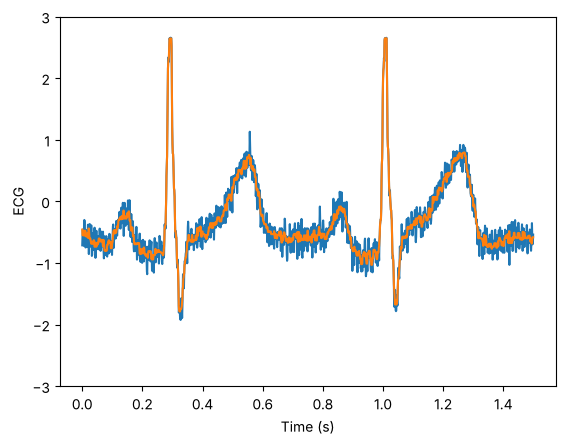

In [1]:
#median filters are already implemented in the scipy library 
import numpy as np
from scipy.signal import medfilt
import matplotlib.pyplot as plt

#load some noisy data captured at 1000 Hz
data=np.loadtxt('data/ecg_hfn.dat')
Fs=1000
time= np.arange(0,len(data)*1/Fs,1/Fs) # time vector
#plot the noisy data
plt.plot(time[0:1500],data[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-3,3])

### Apply a median filter with a window of 9 samples (the window size must be an odd number)
window_size = 9
filtered_signal = medfilt(data,window_size)
plt.plot(time[0:1500],filtered_signal[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-3,3])


## Activity

Change the window size to 7,15,35,51, and 99. What happens to the filtered signal? 

⚠️ Important:
Filtering does NOT recover the “true” signal.
It removes components based on assumptions about what is noise.

Poor filter choices can:
- Remove real movement features
- Shift timing
- Alter peak values


- *Savitzky-Golay filter*:  A Savitzky-Golay (SG) filter replaces every value in a signal with the value derived from a low-order polynomial fitter on a small window around the value.

<div style="text-align: center;">
<img src='images/Savitzky_golay_local_regression_wl045_pd04.gif' alt='Median Filter', width=800, height=400>
</div> 


    Step 1: Augment your signal by mirroring the end.
    
<div style="text-align: center;">
<img src='images/SG_filter_1.png' alt='Median Filter', width=800, height=200>
</div> 


    Step 2: Use the values around a small window and fit a low-order polynomial (usually order 2 or 3).
<div style="text-align: center;">
<img src='images/SG_filter_1a.png' alt='Median Filterp', width=800, height=200>
</div> 


    Step 3: Evaluate the polynomial at the desired index and store the results
<div style="text-align: center;">
<img src='images/SG_filter_2.png' alt='Median Filterp', width=800, height=200>
</div> 


    Step 4: Move the window one step and repeat the process 
<div style="text-align: center;">
<img src='images/SG_filter_3.png' alt='Median Filterp', width=800, height=200>
</div> 

    Step 5: Continue until you process all the data in the signal.
<div style="text-align: center;">
<img src='images/SG_filter_4.png' alt='Median Filterp', width=800, height=200>
</div> 


The resulting signal is smoother than the original. You can adjust the window size and polynomial order to obtain smoother outputs. 

(-3.0, 3.0)

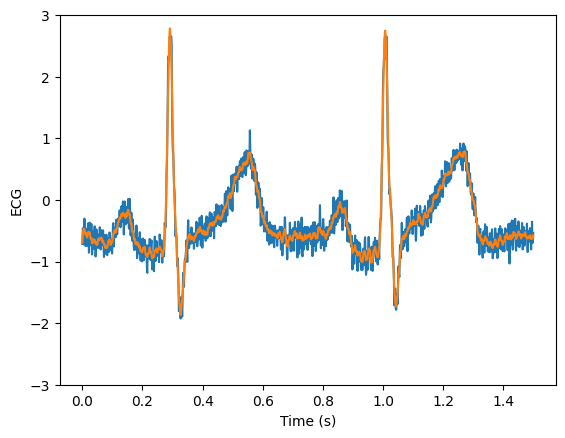

In [4]:
#SG filters are already implemented in the scipy library 
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

#load some noisy data captured at 1000 Hz
data=np.loadtxt('data/ecg_hfn.dat')
Fs=1000
time= np.arange(0,len(data)*1/Fs,1/Fs) # time vector
#plot the noisy data
plt.plot(time[0:1500],data[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-3,3])

### Apply a SG filter with a window of 19 samples and polynomial order 3
filtered_signal = savgol_filter(data, 19, 3)
plt.plot(time[0:1500],filtered_signal[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-3,3])

## Activity

a) Change the window size to 7,15,35,51, and 99. What happens to the filtered signal? 

b) For a window size of 35, change the polynomial order to 4, 8, 16, and 32. What happens to the filtered signal?

_Note:_ The polynomial order must be smaller than the window size.

- *Ensemble filter*:  An ensemble filter uses multiple repetitions of the same process to identify an average across repetitions. Ensemble filters are ideal for signals that represent the same process recorded multiple times.

<div style="text-align: center;">
<img src='images/ensemble_filter.png' alt='Ensemble filter', width=800, height=400>
</div> 

The resulting signal is smoother than the original. You can adjust the number of elements in the ensemble to obtain smoother outputs. 

- *Frequency domain filtering*:

**The Fourier Theorem**
Any reasonably well-behaved periodic function or signal can be expressed as an infinite sum of simple sine waves (harmonics) with specific amplitudes and frequencies. 


<div style="text-align: center;">
<img src='images/Fourier_transform_time_and_frequency_domains.gif' alt='Median Filterp', width=600, height=600>
</div> 

Frequency domain filtering refers to eliminating some of those frequency components. Once those frequency components are removed, it is possible to reconstruct a new signal that does not include the undesired components. 



<div style="text-align: center;">
<img src='images/filter_fourier.png' alt='Median Filterp', width=600, height=200>
</div> 




There are different types of filters depending on the components being removed from the signal:

- *Frequency domain filtering*:
  
  - Low-Pass Filter: Low-Pass filters remove frequency components above a certain threshold, leaving only the low-frequency components of the signal. Low-Pass filters help to smooth a signal.
<div style="text-align: center;">
<img src='images/low-pass.png' alt='Median Filterp', width=300, height=200>
</div> 
  - High-Pass Filter: High-Pass filters remove frequency components below a certain threshold, leaving only the high-frequency components of the signal. High-Pass filters help to detrend a signal. 
<div style="text-align: center;">
<img src='images/high-pass.png' alt='Median Filterp', width=300, height=200>
</div>  
  - Band-Pass Filter: Band-Pass filters keep only the frequency components between a low and a high cutoff. They remove slow trends and high-frequency noise at the same time.
<div style="text-align: center;">
<img src='images/band-pass.png' alt='Median Filterp', width=300, height=200>
</div> 
  - Band-Stop Filter: Band-Stop filters are the opposite of Band-Pass filters. They remove the frequency components between a low and a high cutoff and keep all the other components. Band-Stop filters help remove a specific range of unwanted frequencies. 
<div style="text-align: center;">
<img src='images/stop-band.png' alt='Median Filterp', width=300, height=200>
</div>
  - Notch Filter: Notch filters remove frequency components with a specific frequency. Notch filters help remove power-line interference (50 or 60 Hz). 
<div style="text-align: center;">
<img src='images/notch.png' alt='Median Filterp', width=300, height=200>
</div>



### Before you design a frequency filter

**1. Sampling rate and the Nyquist frequency**

The sampling rate ($F_s$) is the number of samples the sensor records in one second. A signal sampled at $F_s$ can only contain frequencies up to $F_s/2$. This limit is the **Nyquist frequency**.

For example, the ECG below was sampled at 1000 Hz, so it contains frequencies from 0 to 500 Hz. This is why the code divides the cutoff frequencies by `Fs/2`: `butter` expects cutoffs as a fraction of the Nyquist frequency (a value between 0 and 1). You can also give `butter` the cutoffs in Hz with the `fs=` argument. Both ways give the same filter.

**2. Filter order**

The order controls how sharp the transition is between the frequencies you keep and the frequencies you remove. A higher order gives a sharper cut but can cause oscillations. Orders 2 to 4 are common for biosignals.

**3. `filtfilt` (zero-phase filtering)**

All filters delay the signal a little. `filtfilt` applies the filter forward and then backward, so the delays cancel. Use `filtfilt` when the timing of events (for example, heel strike) is important.


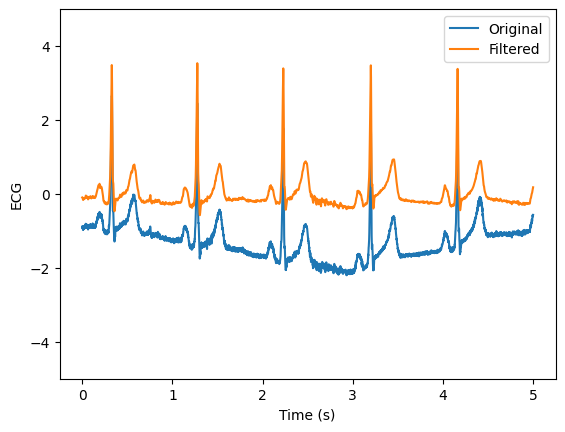

In [5]:
from scipy.signal import butter, filtfilt


data=np.loadtxt( 'data/ecg_lfn.dat' )
Fs=1000
time= np.arange(0,len(data)*1/Fs,1/Fs) # time vector
#plot the noisy data
plt.plot(time[0:5000],data[0:5000], label='Original')
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-5,5])


#design and apply a band-pass filter. For ECG, we usually keep the frequencies between 0.5 and 100 Hz
#the cutoffs are divided by the Nyquist frequency (Fs/2)
low_cf = 0.5 / (Fs/2)
high_cf = 100 / (Fs/2)
b, a = butter(4, [low_cf, high_cf], btype='bandpass') #design the filter (order 4)
filtered_signal = filtfilt(b,a,data) #apply the filter
plt.plot(time[0:5000],filtered_signal[0:5000], label='Filtered')
plt.legend();

To look at the frequency content of a signal and understand the effect of the filters, you can use the periodogram.

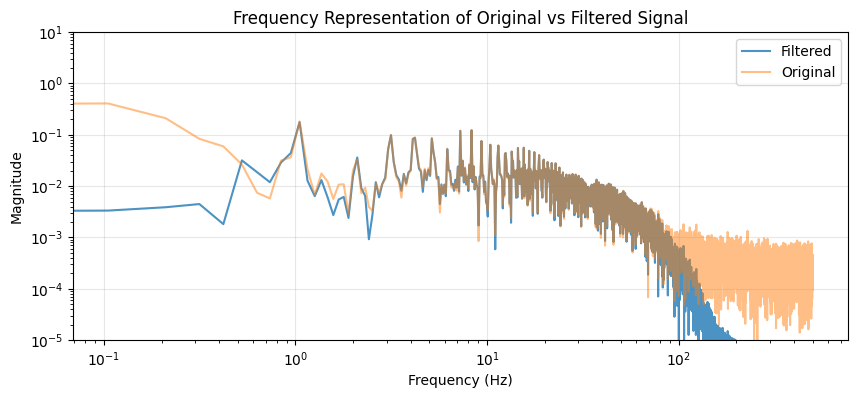

In [6]:
from scipy.signal import periodogram

# Frequency representation (magnitude spectrum) using periodogram

freqs, orig_psd = periodogram(data, fs=Fs, scaling='spectrum')
_, filt_psd = periodogram(filtered_signal, fs=Fs, scaling='spectrum')

# Convert power spectrum to magnitude-like scale
orig_mag = np.sqrt(orig_psd)
filt_mag = np.sqrt(filt_psd)

plt.figure(figsize=(10, 4))
plt.loglog(freqs, filt_mag, label='Filtered', alpha=0.8)
plt.loglog(freqs, orig_mag, label='Original', alpha=0.5)
plt.ylim(10e-6, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Representation of Original vs Filtered Signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Note: The frequencies to keep depend on the physiological process that you analyze. We usually remove components below 0.5 Hz to remove undesired slow trends (drift).

**Typical frequencies of human movement and noise**

| Component | Typical frequency |
|---|---|
| Walking (steps) | 1 to 2.5 Hz |
| Running (steps) | 2.5 to 3.5 Hz |
| Most voluntary movement | below 6 to 10 Hz |
| Parkinson's rest tremor | 4 to 6 Hz |
| Essential or physiological tremor | 6 to 12 Hz |
| Sensor noise and impacts | above 15 to 20 Hz |
| Power line | 50 or 60 Hz |
| Surface EMG | 20 to 450 Hz |

Rule of thumb:
- Slow, voluntary movement → low frequencies
- Faster movements and tremor → higher frequencies
- Noise often dominates above the physiological movement frequencies

In the next cell, you will see these frequencies in a real walking signal. You will use this same signal in the next lecture (03.04).


Sampling rate = 100 Hz, Nyquist frequency = 50 Hz


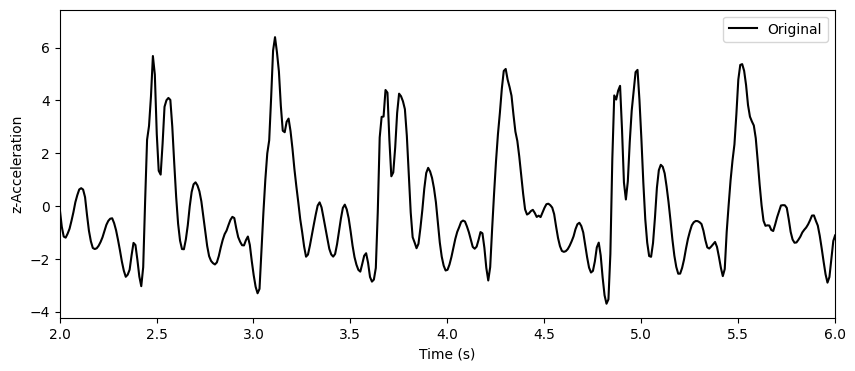

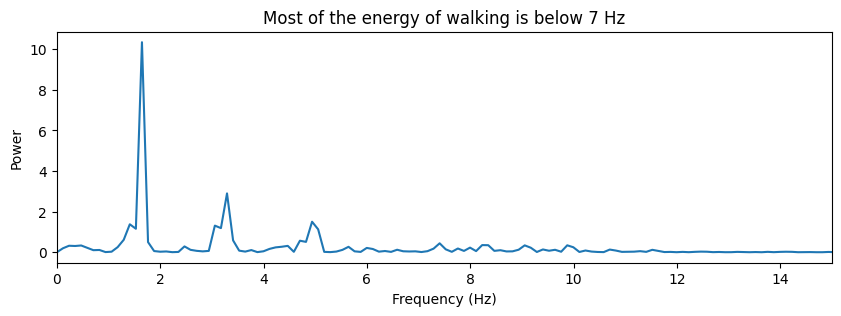

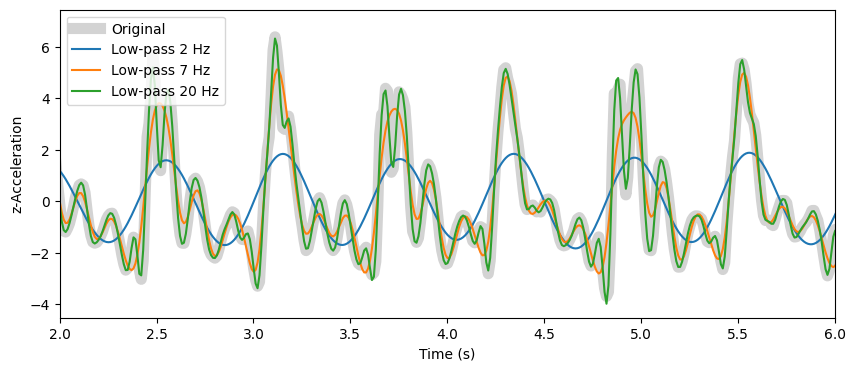

In [11]:
# Filtering a movement signal: acceleration recorded at the center of mass during walking
import pandas as pd

walk = pd.read_csv('data/accelerationSteps.csv')
fs_walk = 1/np.median(np.diff(walk['time']))   # sampling rate (about 100 Hz)
acc_z = walk['z'].values
print(f'Sampling rate = {fs_walk:.0f} Hz, Nyquist frequency = {fs_walk/2:.0f} Hz')


# 1) Low-pass filters with three different cutoffs
plt.figure(figsize=(10, 4))
plt.plot(walk['time'], acc_z, color='black', label='Original')
plt.xlim(2, 6)
plt.xlabel('Time (s)')
plt.ylabel('z-Acceleration')
plt.legend()
plt.show()

# 2) Frequency content: where is the energy of walking?
freqs_w, psd_w = periodogram(acc_z - np.mean(acc_z), fs=fs_walk)
plt.figure(figsize=(10, 3))
plt.plot(freqs_w, psd_w)
plt.xlim(0, 15)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Most of the energy of walking is below 7 Hz')
plt.show()

# 3) Low-pass filters with three different cutoffs
plt.figure(figsize=(10, 4))
plt.plot(walk['time'], acc_z, color='lightgray', label='Original', lw=8)
for cutoff in [2, 7, 20]:
    b, a = butter(4, cutoff, btype='low', fs=fs_walk)   # cutoff given in Hz with fs=
    plt.plot(walk['time'], filtfilt(b, a, acc_z), label=f'Low-pass {cutoff} Hz')
plt.xlim(2, 6)
plt.xlabel('Time (s)')
plt.ylabel('z-Acceleration')
plt.legend()
plt.show()


## Activity

a) Which cutoff removes too much? Which cutoff keeps too much noise?

b) Find the highest peak in the frequency plot. How many steps per second does it represent?


### Key Takeaways

- Biosignals from human movement are always noisy
- Filtering is a modeling decision, not just a technical step
- Different filters remove different types of noise

**Filter-Specific Insights**

- Median filters are effective for removing spikes and tracking errors
- Ensemble filters exploit repetition to reduce random noise but hide variability
- Low-pass filters preserve slow, voluntary movement while removing high-frequency noise
- High-pass filters remove slow trends but can eliminate meaningful motion
- Band-pass filters isolate specific physiological phenomena (e.g., tremor)

**Frequency-Domain Thinking**

- Movement signals are dominated by low frequencies
- Noise often appears at higher frequencies
- Fourier analysis helps guide filter design, even if filters are applied in time
